 Online Retail Recommendation System

Importing Libraries and Dataset loading and initial description
   The dataset is 'OnlineRetail.csv' as provided, containing online retail transactions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

dataset_path = 'Online_Retail.csv' 

try:
    df_retail = pd.read_csv(dataset_path, encoding='latin1')
    print(f"Successfully loaded dataset from: {dataset_path}")
except FileNotFoundError:
    print(f"ERROR: Dataset file '{dataset_path}' not found.")
    print("Please ensure the file is in the correct location or update the 'dataset_path' variable in the script.")
    df_retail = None 

Successfully loaded dataset from: Online_Retail.csv


In [2]:
df_retail

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


Initial Statistics: You can include output from df.info() and df.describe() here, or summarize key findings from them.

In [3]:
if df_retail is not None:
    print("Dataset Shape:", df_retail.shape)
    print("\nFirst 5 rows of the dataset:")
    print(df_retail.head())

    print("\nDataset Info:")
    df_retail.info()

    print("\nDescriptive Statistics:")
    print(df_retail.describe(include='all'))
else:
    print("Dataset could not be loaded. Please check the file path and try again.")

Dataset Shape: (541909, 8)

First 5 rows of the dataset:
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Coun

Data preprocessing and EDA  

In [4]:
if df_retail is not None:
    # 3.1 Handling Missing Values

    print("Missing values before cleaning:")
    print(df_retail.isnull().sum())

    # Drop rows where CustomerID is missing, as it's often important for user-based analysis
    # For purely popularity-based on StockCode, this might be optional, but good practice.
    df_retail.dropna(subset=['CustomerID'], inplace=True)

    # Fill missing Descriptions with 'UNKNOWN' or drop them.
    # For popularity, Description is key for human readability.
    df_retail.dropna(subset=['Description'], inplace=True) # Drop rows with missing description

    print("\nMissing values after CustomerID & Description handling:")
    print(df_retail.isnull().sum())
    print("Dataset Shape after handling missing values:", df_retail.shape)

Missing values before cleaning:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Missing values after CustomerID & Description handling:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64
Dataset Shape after handling missing values: (406829, 8)


3.2 Data cleaning 

In [5]:
    # - Remove cancelled transactions (InvoiceNo starts with 'C').
    # - Remove items with negative or zero quantity.
    # - Remove items with zero or negative unit price.
    # - Remove rows where StockCode might be non-product related (e.g., 'POST', 'D', 'M', 'BANK CHARGES', 'CRUK')df_retail['InvoiceNo'] = df_retail['InvoiceNo'].astype(str)
df_retail = df_retail[~df_retail['InvoiceNo'].str.startswith('C', na=False)]

    # Remove rows with non-positive Quantity
df_retail = df_retail[df_retail['Quantity'] > 0]

    # Remove rows with non-positive UnitPrice (or very low, e.g., < 0.001)
df_retail = df_retail[df_retail['UnitPrice'] > 0.001] 

    # Remove common non-product stock codes (this list can be expanded based on EDA)
non_product_codes = ['POST', 'D', 'M', 'BANK CHARGES', 'CRUK', 'S', 'AMAZONFEE', 'DOT', 'TEST001', 'TEST002', 'ADJUST', 'ADJUST2']
df_retail = df_retail[~df_retail['StockCode'].astype(str).isin(non_product_codes)]
    # Also, some descriptions might indicate non-product items
df_retail = df_retail[~df_retail['Description'].astype(str).str.contains('POSTAGE|CARRIAGE|Manual|Discount|AMAZON FEE', case=False, na=False)]

print("\nDataset Shape after cleaning (cancellations, quantity, price, non-product codes):", df_retail.shape)


Dataset Shape after cleaning (cancellations, quantity, price, non-product codes): (396196, 8)


 Data Type Conversion & Feature Engineering

In [6]:
df_retail['InvoiceDate'] = pd.to_datetime(df_retail['InvoiceDate'])

    # Extract Month and Year
df_retail['Year'] = df_retail['InvoiceDate'].dt.year
df_retail['Month'] = df_retail['InvoiceDate'].dt.month
df_retail['MonthName'] = df_retail['InvoiceDate'].dt.strftime('%B') # For better display

    # Create TotalPrice column
df_retail['TotalPrice'] = df_retail['Quantity'] * df_retail['UnitPrice']

print("\nData with new features (Year, Month, TotalPrice):")
print(df_retail[['InvoiceDate', 'Year', 'Month', 'MonthName', 'TotalPrice']].head())


Data with new features (Year, Month, TotalPrice):
          InvoiceDate  Year  Month MonthName  TotalPrice
0 2010-12-01 08:26:00  2010     12  December       15.30
1 2010-12-01 08:26:00  2010     12  December       20.34
2 2010-12-01 08:26:00  2010     12  December       22.00
3 2010-12-01 08:26:00  2010     12  December       20.34
4 2010-12-01 08:26:00  2010     12  December       20.34


 Architecture Implementation: Finding Popular Items

 Globally Popular Items

In [7]:
 
globally_popular_items = df_retail.groupby(['StockCode', 'Description'])['Quantity'].sum().sort_values(ascending=False)

print("Top 10 Globally Popular Items:")
print(globally_popular_items.head(10))

Top 10 Globally Popular Items:
StockCode  Description                       
23843      PAPER CRAFT , LITTLE BIRDIE           80995
23166      MEDIUM CERAMIC TOP STORAGE JAR        77916
84077      WORLD WAR 2 GLIDERS ASSTD DESIGNS     54415
85099B     JUMBO BAG RED RETROSPOT               46181
85123A     WHITE HANGING HEART T-LIGHT HOLDER    36725
84879      ASSORTED COLOUR BIRD ORNAMENT         35362
21212      PACK OF 72 RETROSPOT CAKE CASES       33693
22197      POPCORN HOLDER                        30931
23084      RABBIT NIGHT LIGHT                    27202
22492      MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64


C:\Users\DELL\AppData\Local\Temp\ipykernel_10936\2352580478.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=global_desc_short,


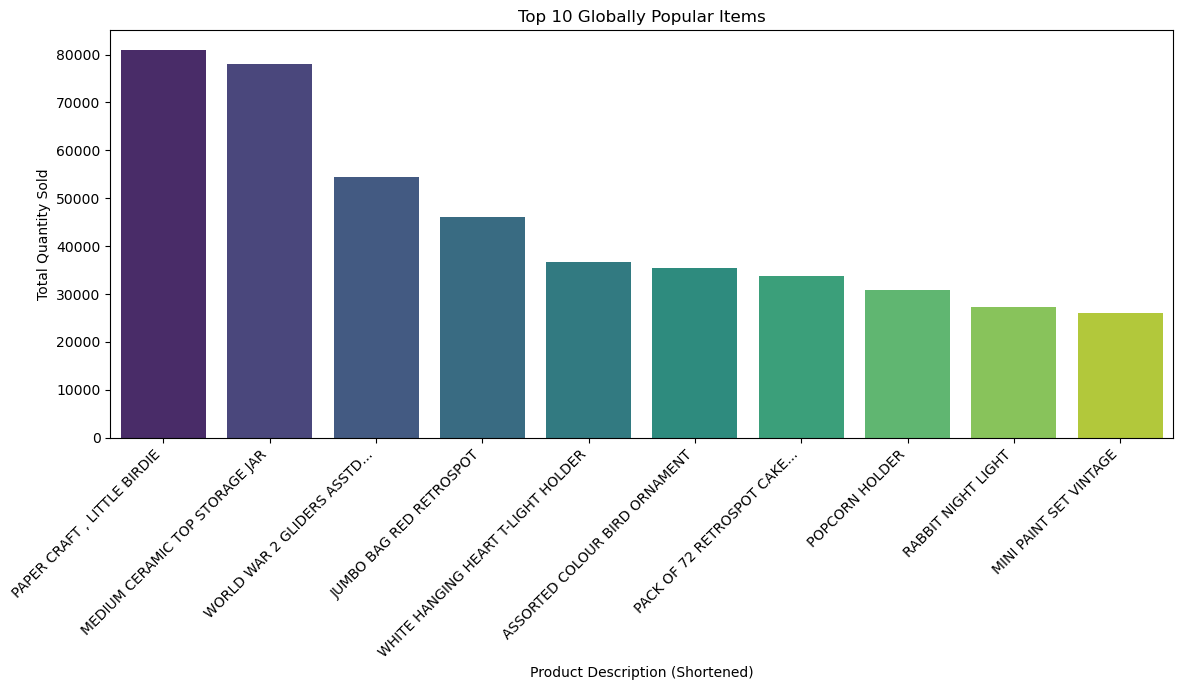

In [8]:
# visualizing using seaborn
plt.figure(figsize=(12, 7)) # Adjusted size
top_n_global = 10
    # Taking only the first few words of description for cleaner plot labels
global_desc_short = [' '.join(desc.split()[:5]) + ('...' if len(desc.split()) > 5 else '') for desc in globally_popular_items.head(top_n_global).index.get_level_values('Description')]
    
sns.barplot(x=global_desc_short,
y=globally_popular_items.head(top_n_global).values,
                palette='viridis')
plt.xlabel("Product Description (Shortened)")
plt.ylabel("Total Quantity Sold")
plt.title(f"Top {top_n_global} Globally Popular Items")
plt.xticks(rotation=45, ha='right') # Adjusted rotation
plt.tight_layout()
plt.show()

 country-wise popular items

In [9]:

country_popular_items = df_retail.groupby(['Country', 'StockCode', 'Description'])['Quantity'].sum().reset_index()
country_popular_items = country_popular_items.sort_values(['Country', 'Quantity'], ascending=[True, False])

country_example = 'France' # Example country
print(f"\nAvailable countries: {df_retail['Country'].nunique()}")
print(f"Top 5 countries by sales volume: {df_retail.groupby('Country')['Quantity'].sum().nlargest(5).index.tolist()}")

if country_example in country_popular_items['Country'].unique():
            top_items_country = country_popular_items[country_popular_items['Country'] == country_example].head(10)
print(f"\nTop 10 Popular Items in {country_example}:")
print(top_items_country[['Description', 'Quantity']])


Available countries: 37
Top 5 countries by sales volume: ['United Kingdom', 'Netherlands', 'EIRE', 'Germany', 'France']

Top 10 Popular Items in France:
                           Description  Quantity
6637                RABBIT NIGHT LIGHT      4000
6254            MINI PAINT SET VINTAGE      2196
5913     RED TOADSTOOL LED NIGHT LIGHT      1291
5708       SET/6 RED SPOTTY PAPER CUPS      1272
7053     ASSORTED COLOUR BIRD ORNAMENT      1204
5759   PACK OF 72 RETROSPOT CAKE CASES      1176
6296  PLASTERS IN TIN WOODLAND ANIMALS      1144
6298     PLASTERS IN TIN CIRCUS PARADE      1144
5712     SET/6 RED SPOTTY PAPER PLATES      1116
6294          PLASTERS IN TIN SPACEBOY      1012


C:\Users\DELL\AppData\Local\Temp\ipykernel_11616\3649022186.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_desc_short,


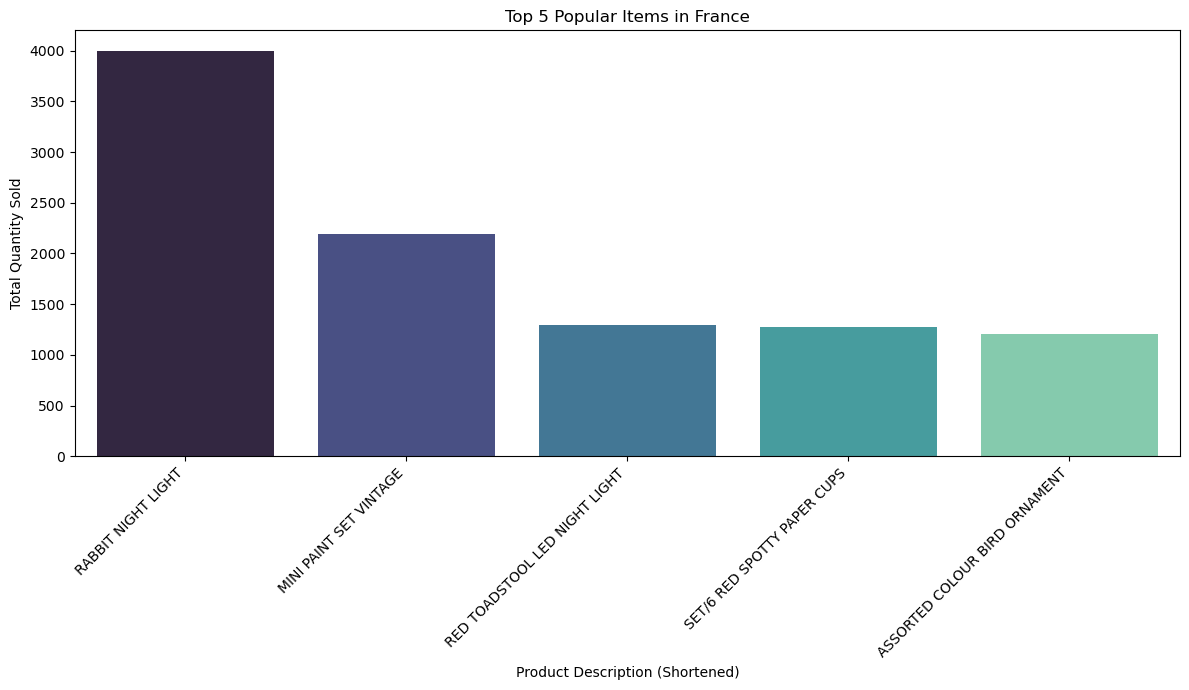

In [67]:
#visualization
plt.figure(figsize=(12, 7)) # Adjusted size
 top_n_country = 5
 country_desc_short = [' '.join(desc.split()[:5]) + ('...' if len(desc.split()) > 5 else '') for desc in top_items_country.head(top_n_country)['Description']]

 sns.barplot(x=country_desc_short,
                    y=top_items_country.head(top_n_country)['Quantity'],
                    palette='mako')
 plt.xlabel("Product Description (Shortened)")
 plt.ylabel("Total Quantity Sold")
 plt.title(f"Top {top_n_country} Popular Items in {country_example}")
 plt.xticks(rotation=45, ha='right') # Adjusted rotation
 plt.tight_layout()
 plt.show()

 Month-wise popular items

In [11]:
month_popular_items = df_retail.groupby(['Year', 'Month', 'MonthName', 'StockCode', 'Description'])['Quantity'].sum().reset_index()
month_popular_items = month_popular_items.sort_values(['Year', 'Month', 'Quantity'], ascending=[True, True, False])

    # Example: Top items in a specific month and year
    # Let's pick a month with likely high sales, e.g., November 2011 (pre-Christmas)
year_example = 2011
month_example_num = 11 # November
month_example_name = datetime(2000, month_example_num, 1).strftime('%B')


filtered_month_data = month_popular_items[
        (month_popular_items['Year'] == year_example) & (month_popular_items['Month'] == month_example_num)
    ]

if not filtered_month_data.empty:
         top_items_month_year = filtered_month_data.head(10)
print(f"\nTop 10 Popular Items in {month_example_name} {year_example}:")
print(top_items_month_year[['Description', 'Quantity']])


Top 10 Popular Items in November 2011:
                               Description  Quantity
27364                   RABBIT NIGHT LIGHT     12393
26620                       POPCORN HOLDER      8458
26531       PAPER CHAIN KIT 50'S CHRISTMAS      5919
28310              JUMBO BAG RED RETROSPOT      5678
28207        ASSORTED COLOUR BIRD ORNAMENT      5190
26928   WOODEN STAR CHRISTMAS SCANDINAVIAN      4981
28320   WHITE HANGING HEART T-LIGHT HOLDER      4861
26927  WOODEN HEART CHRISTMAS SCANDINAVIAN      4582
28100    WORLD WAR 2 GLIDERS ASSTD DESIGNS      4500
25873      DISCO BALL CHRISTMAS DECORATION      4391


In [13]:
month_popular_items = df_retail.groupby(['Year', 'Month', 'MonthName', 'StockCode', 'Description'])['Quantity'].sum().reset_index()
month_popular_items = month_popular_items.sort_values(['Year', 'Month', 'Quantity'], ascending=[True, True, False])

    # Example: Top items in a specific month and year
    # Let's pick a month with likely high sales, e.g., June 2011
year_example = 2011
month_example_num = 6 # June
month_example_name = datetime(2000, month_example_num, 1).strftime('%B')


filtered_month_data = month_popular_items[
        (month_popular_items['Year'] == year_example) & (month_popular_items['Month'] == month_example_num)
    ]

if not filtered_month_data.empty:
         top_items_month_year = filtered_month_data.head(10)
print(f"\nTop 10 Popular Items in {month_example_name} {year_example}:")
print(top_items_month_year[['Description', 'Quantity']])


Top 10 Popular Items in June 2011:
                               Description  Quantity
15629              JUMBO BAG RED RETROSPOT      3529
13411            ASSORTED COLOURS SILK FAN      3096
13454                   BROCADE RING PURSE      2988
14543            PACK OF 12 LONDON TISSUES      2397
15499  COLOUR GLASS T-LIGHT HOLDER HANGING      2204
15160   SET OF 60 PANTRY DESIGN CAKE CASES      2123
14364              JUMBO BAG PINK POLKADOT      2036
15631                 JUMBO BAG STRAWBERRY      1988
15067            JUMBO BAG DOILEY PATTERNS      1948
15403    WORLD WAR 2 GLIDERS ASSTD DESIGNS      1920


C:\Users\DELL\AppData\Local\Temp\ipykernel_11616\1082395055.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=month_desc_short,


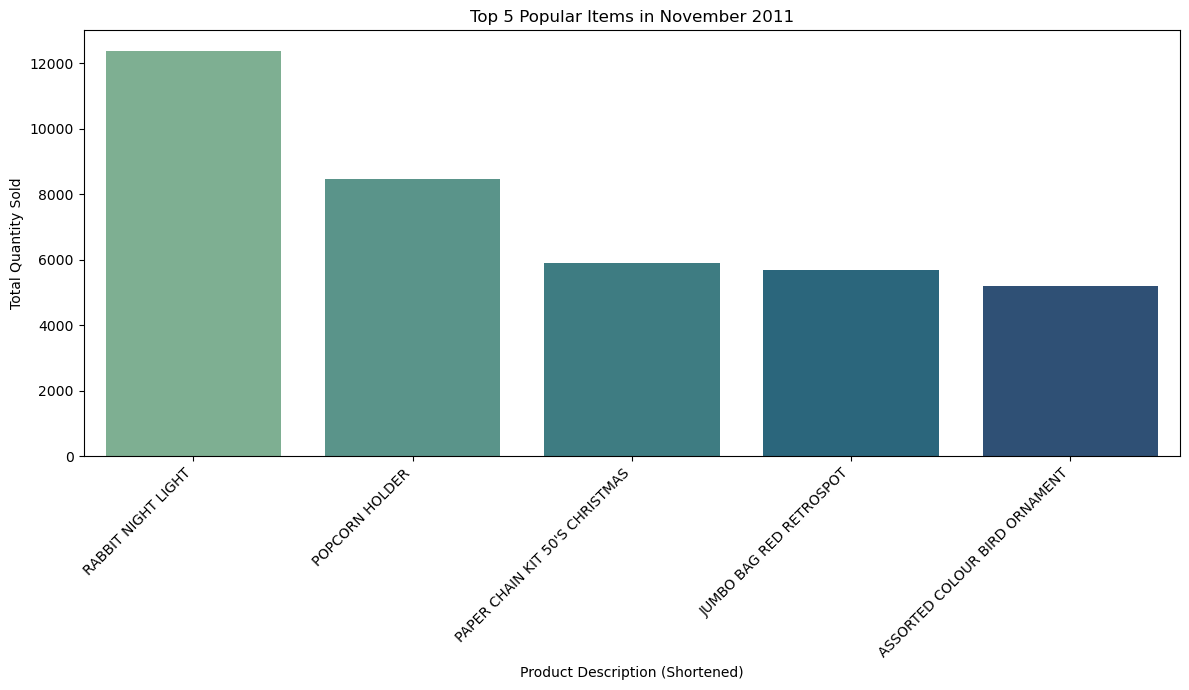

In [126]:
#visualization
plt.figure(figsize=(12, 7)) # Adjusted size
top_n_month = 5
month_desc_short = [' '.join(desc.split()[:5]) + ('...' if len(desc.split()) > 5 else '') for desc in top_items_month_year.head(top_n_month)['Description']]
        
sns.barplot(x=month_desc_short,
                    y=top_items_month_year.head(top_n_month)['Quantity'],
                    palette='crest')
plt.xlabel("Product Description (Shortened)")
plt.ylabel("Total Quantity Sold")
plt.title(f"Top {top_n_month} Popular Items in {month_example_name} {year_example}")
plt.xticks(rotation=45, ha='right') # Adjusted rotation
plt.tight_layout()
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_10936\1988669725.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=month_desc_short,


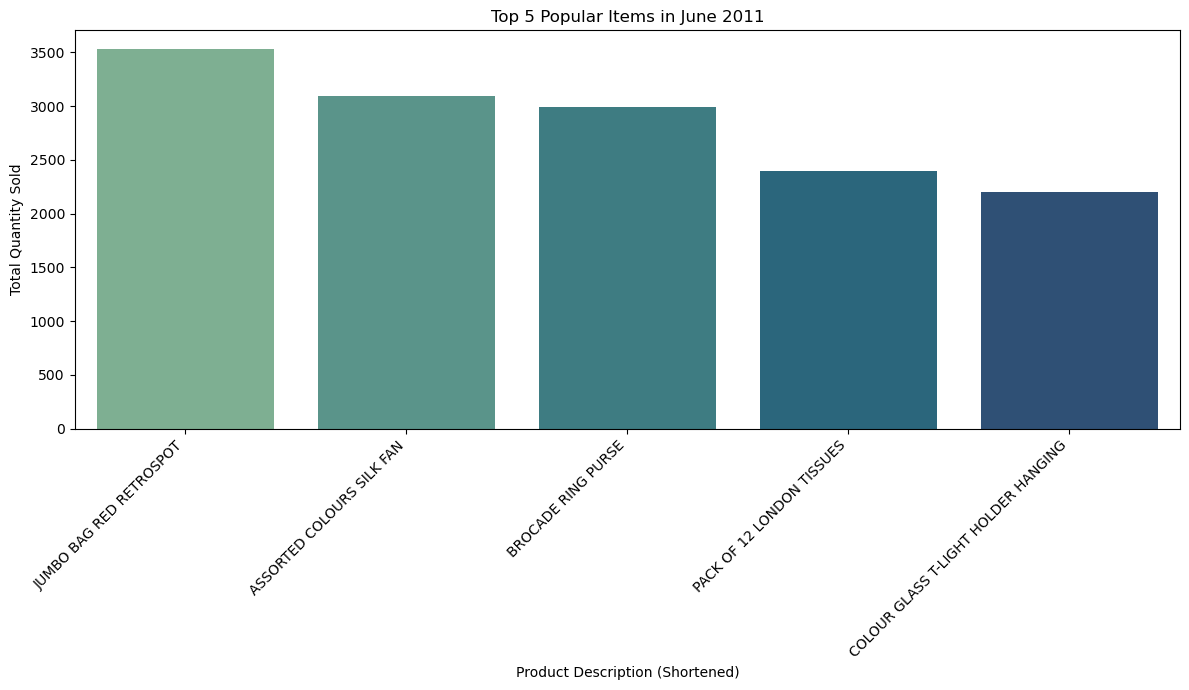

In [14]:
#visualization
plt.figure(figsize=(12, 7)) # Adjusted size
top_n_month = 5
month_desc_short = [' '.join(desc.split()[:5]) + ('...' if len(desc.split()) > 5 else '') for desc in top_items_month_year.head(top_n_month)['Description']]
        
sns.barplot(x=month_desc_short,
                    y=top_items_month_year.head(top_n_month)['Quantity'],
                    palette='crest')
plt.xlabel("Product Description (Shortened)")
plt.ylabel("Total Quantity Sold")
plt.title(f"Top {top_n_month} Popular Items in {month_example_name} {year_example}")
plt.xticks(rotation=45, ha='right') # Adjusted rotation
plt.tight_layout()
plt.show()

Function to Analyze and print recommendations (predict)

In [69]:
def get_global_recommendations(data, top_n=5):
        """Returns the top N globally popular items."""
        if data is None or data.empty:
            return "Dataset not loaded or is empty."
        popular_items = data.groupby(['StockCode', 'Description'])['Quantity'].sum().sort_values(ascending=False)
        return popular_items.head(top_n)
def get_country_recommendations(data, country, top_n=5):
        """Returns the top N popular items for a specific country."""
        if data is None or data.empty:
            return "Dataset not loaded or is empty."
        country_data = data[data['Country'] == country]
        if country_data.empty:
            return pd.Series(dtype='float64', name=f"No data available for country: {country}") # Return empty Series for consistency
        popular_items = country_data.groupby(['StockCode', 'Description'])['Quantity'].sum().sort_values(ascending=False)
        return popular_items.head(top_n)
def get_month_recommendations(data, year, month_num, top_n=5): # Changed to month_num
       
        #Returns the top N popular items for a specific year and month number."""
        if data is None or data.empty:
            return "Dataset not loaded or is empty."
        
        month_name = datetime(2000, month_num, 1).strftime('%B')
        month_data = data[(data['Year'] == year) & (data['Month'] == month_num)]
        if month_data.empty:
            return pd.Series(dtype='float64', name=f"No data available for {month_name} {year}") # Return empty Series
        popular_items = month_data.groupby(['StockCode', 'Description'])['Quantity'].sum().sort_values(ascending=False)
        return popular_items.head(top_n)

 Demonstration of Recommendation System

In [55]:
if df_retail is not None and not df_retail.empty:
        print("--- Global Recommendations ---")
        global_recs = get_global_recommendations(df_retail, top_n=5)
        print(global_recs)
        print("-" * 30)

        target_country = 'Germany' # A country likely to have data
        print(f"\n--- {target_country} Recommendations ---")
        country_recs = get_country_recommendations(df_retail, country=target_country, top_n=5)
        if isinstance(country_recs, pd.Series) and not country_recs.empty:
            print(country_recs)
        else:
            print(f"No recommendations for {target_country} (or data empty).")
        print("-" * 30)

        target_year = 2011
        target_month = 11 # November
        month_name_display = datetime(2000, target_month, 1).strftime('%B')
        print(f"\n--- {month_name_display} {target_year} Recommendations ---")
        month_recs = get_month_recommendations(df_retail, year=target_year, month_num=target_month, top_n=5)
        if isinstance(month_recs, pd.Series) and not month_recs.empty:
            print(month_recs)
        else:
            print(f"No recommendations for {month_name_display} {target_year} (or data empty).")
        print("-" * 30)

        # Example for a country that might not exist or have little data
        target_country_no_data = 'Neverland'
        print(f"\n--- {target_country_no_data} Recommendations ---")
        country_recs_no_data = get_country_recommendations(df_retail, country=target_country_no_data, top_n=5)
        if isinstance(country_recs_no_data, pd.Series) and not country_recs_no_data.empty:
            print(country_recs_no_data)
        else: # This branch will likely be taken if 'Neverland' is not in the data
            print(f"No recommendations for {target_country_no_data} (or data empty).")
        print("-" * 30)
else:
        print("Skipping recommendation demonstration as dataset was not loaded or is empty after processing.")


--- Global Recommendations ---
StockCode  Description                       
23843      PAPER CRAFT , LITTLE BIRDIE           80995
23166      MEDIUM CERAMIC TOP STORAGE JAR        77916
84077      WORLD WAR 2 GLIDERS ASSTD DESIGNS     54415
85099B     JUMBO BAG RED RETROSPOT               46181
85123A     WHITE HANGING HEART T-LIGHT HOLDER    36725
Name: Quantity, dtype: int64
------------------------------

--- Germany Recommendations ---
StockCode  Description                       
22326      ROUND SNACK BOXES SET OF4 WOODLAND    1233
15036      ASSORTED COLOURS SILK FAN             1164
20719      WOODLAND CHARLOTTE BAG                1020
21212      PACK OF 72 RETROSPOT CAKE CASES       1002
22585      PACK OF 6 BIRDY GIFT TAGS              936
Name: Quantity, dtype: int64
------------------------------

--- November 2011 Recommendations ---
StockCode  Description                   
23084      RABBIT NIGHT LIGHT                12393
22197      POPCORN HOLDER                     8